# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MuhammadFaizan0023/FlyRank_ML_internship_repo/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import seaborn as sns
import os
import re

In [6]:
data = pd.read_csv("data_for_baseline_action_score.csv")

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*



The queue is ordered by how strongly the available signals agree that a page has declined, not by predicted content strategy. At the extremes of the score range, the model's evaluated accuracy is highest (F1 ~0.75), so a human can act on those rankings with more confidence. In the middle of the score range, the same score can arise from different combinations of reason codes, and model accuracy is weaker (F1 ~0.42-0.58) — so "what to do first" there means "look here next, but verify manually before treating the ranking as decisive," rather than treating the order as a strict priority list.

**Reason codes**<br>
IF gsc_clicks_last30 ≤ gsc_clicks_prev30 OR IF gsc_impressions_last30 ≤ gsc_impressions_prev30 OR IF gsc_avg_position_last30 ≥ gsc_avg_position_prev30 OR IF ctr_last30 < ctr_prev30 OR IF engagement_rate_last30 ≤ engagement_rate_prev30 OR IF scroll_events_rate_last30 ≤ scroll_events_rate_prev30 OR IF ga4_pageviews_last30 ≤ ga4_pageviews_prev30 OR IF ga4_users_last30 ≤ ga4_users_prev30 OR IF ga4_total_engagement_sec_last30 ≤ ga4_total_engagement_sec_prev30 OR IF sessions_organic_last30 ≤ sessions_organic_prev30 OR IF sessions_direct_last30 ≤ sessions_direct_prev30 OR IF sessions_referral_last30 ≤ sessions_referral_prev30 OR IF sessions_social_last30 ≤ sessions_social_prev30 OR IF sessions_paid_last30 ≤ sessions_paid_prev30 OR IF sessions_ai_last30 ≤ sessions_ai_prev30 OR IF scroll_events_last30 ≤ scroll_events_prev30 OR IF cpc_last30 ≤ cpc_prev30

**Sorted ranked queue**

In [7]:
ranked_queue = data.sort_values('decline_score', ascending=False)

**Ranked Queue**

In [8]:
ranked_queue[:20]

,client_hash_id,content_hash_id,gsc_impressions_prev30d,gsc_clicks_prev30d,gsc_avg_position_prev30d,ga4_pageviews_prev30d,ga4_sessions_prev30d,ga4_users_prev30d,'ga4_engaged_session_prev30,ga4_total_engagement_sec_prev30,...,sessions_paid_last30,sessions_ai_last30,scroll_events_last30,cpc_last30,backlinks_last30,ctr_last30,engagement_rate_last30,scroll_events_rate_last30,days_since_update_last30,decline_score
141355,client_20259bd6705d81d4,content_bff6079940ef8faf,513,7,20.725146,8,7,6,0,0,...,0,0,0,0.00,0.0,0.004292,0.0,0.000000,47,17
141356,client_20259bd6705d81d4,content_dbf35ea262d38fb3,1254,5,23.271132,7,7,7,0,0,...,0,0,0,0.00,0.0,0.002564,0.0,0.000000,47,17
141357,client_20259bd6705d81d4,content_ba1b42d3d9cf77d0,90,1,4.388889,3,3,3,0,1,...,0,0,1,0.00,0.0,0.000000,0.0,1.000000,47,17
141358,client_20259bd6705d81d4,content_bff6079940ef8faf,513,7,20.725146,8,7,6,0,0,...,0,0,2,0.00,0.0,0.010893,0.0,0.333333,47,17
141359,client_20259bd6705d81d4,content_bff6079940ef8faf,513,7,20.725146,8,7,6,0,0,...,0,0,0,0.00,0.0,0.002304,0.0,0.000000,47,17
141328,client_20259bd6705d81d4,content_030054976ef226d1,471,5,10.350318,4,4,4,0,0,...,0,0,0,0.00,0.0,0.009132,0.0,0.000000,47,17
141329,client_23a62021009f63c4,content_7ff47b1364f9351d,929,6,16.503767,7,7,7,3,290,...,0,0,0,0.00,0.0,0.000000,0.0,0.000000,18,17
141330,client_23a62021009f63c4,content_7ff47b1364f9351d,929,6,16.503767,7,7,7,3,290,...,0,0,0,0.00,0.0,0.000000,0.0,0.000000,18,17
141331,client_23a62021009f63c4,content_6d159b4985b766e8,42,1,12.142857,2,1,1,0,0,...,0,0,0,0.00,0.0,0.000000,0.0,0.000000,11,17
141332,client_20259bd6705d81d4,content_40827fb92be7f5bf,379,9,5.620053,8,7,7,0,0,...,0,0,1,0.00,0.0,0.010870,0.0,0.500000,47,17


**Summary statistics for the top decline targets to verify signals**

In [9]:
top_queue = ranked_queue.head(20)

# Let's inspect the key metrics of the highest decline-score pages
summary_stats = top_queue[[
    'decline_score',
    'ga4_pageviews_prev30d',
    'ga4_pageviews_last30d',
    'gsc_impressions_prev30d',
    'gsc_impressions_last30d',
    'gsc_clicks_prev30d',
    'gsc_clicks_last30d',
    'gsc_avg_position_prev30d',
    'gsc_avg_position_last30d',
    'ga4_sessions_prev30d',
    'ga4_sessions_last30d',
    'ga4_users_prev30d',
    'ga4_users_last30d',
    "'ga4_engaged_session_prev30",
    "'ga4_engaged_session_last30",
    'ga4_total_engagement_sec_prev30',
    'ga4_total_engagement_sec_last30',
    'sessions_organic_prev30',
    'sessions_organic_last30',
    'sessions_direct_prev30',
    'sessions_direct_last30',
    'sessions_referral_prev30',
    'sessions_referral_last30',
    'sessions_social_prev30',
    'sessions_social_last30',
    'sessions_paid_prev30',
    'sessions_paid_last30',
    'sessions_ai_prev30',
    'sessions_ai_last30',
    'scroll_events_prev30',
    'scroll_events_last30',
    'cpc_prev30',
    'cpc_last30',
    'backlinks_prev30',
    'backlinks_last30',
    'ctr_prev30',
    'ctr_last30',
    'engagement_rate_prev30',
    'engagement_rate_last30',
    'scroll_events_rate_prev30',
    'scroll_events_rate_last30',
    'days_since_update_last30'
]].describe()

display(summary_stats)

,decline_score,ga4_pageviews_prev30d,ga4_pageviews_last30d,gsc_impressions_prev30d,gsc_impressions_last30d,gsc_clicks_prev30d,gsc_clicks_last30d,gsc_avg_position_prev30d,gsc_avg_position_last30d,ga4_sessions_prev30d,...,cpc_last30,backlinks_prev30,backlinks_last30,ctr_prev30,ctr_last30,engagement_rate_prev30,engagement_rate_last30,scroll_events_rate_prev30,scroll_events_rate_last30,days_since_update_last30
count,20.0,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,...,20.000000,16.00,16.00,20.000000,20.000000,20.000000,20.0,20.000000,20.000000,20.000000
mean,17.0,4.700000,1.950000,792.450000,332.950000,4.000000,0.900000,10.935738,17.376915,4.250000,...,0.200000,29.75,29.75,0.011741,0.003796,0.064286,0.0,0.266071,0.091667,35.100000
std,0.0,2.451637,1.316894,657.776356,253.842155,2.554665,1.209611,7.030755,8.678358,2.468219,...,0.768895,119.00,119.00,0.013815,0.004762,0.157006,0.0,0.295071,0.250584,14.552627
min,17.0,2.000000,1.000000,42.000000,21.000000,1.000000,0.000000,3.038674,5.224490,1.000000,...,0.000000,0.00,0.00,0.000519,0.000000,0.000000,0.0,0.000000,0.000000,11.000000
25%,17.0,2.750000,1.000000,430.750000,133.250000,1.000000,0.000000,5.189656,9.860265,2.750000,...,0.000000,0.00,0.00,0.005841,0.000000,0.000000,0.0,0.000000,0.000000,23.250000
50%,17.0,4.000000,2.000000,513.000000,327.000000,3.500000,1.000000,8.138329,15.004536,3.500000,...,0.000000,0.00,0.00,0.006696,0.002329,0.000000,0.0,0.250000,0.000000,47.000000
75%,17.0,7.000000,2.000000,1010.250000,427.250000,6.000000,1.000000,16.503767,22.778852,7.000000,...,0.000000,0.00,0.00,0.013645,0.006074,0.000000,0.0,0.446429,0.000000,47.000000
max,17.0,8.000000,6.000000,1925.000000,1035.000000,9.000000,5.000000,23.271132,35.360731,7.000000,...,3.420000,476.00,476.00,0.062500,0.016129,0.428571,0.0,1.000000,1.000000,49.000000


**Plot summary stats**

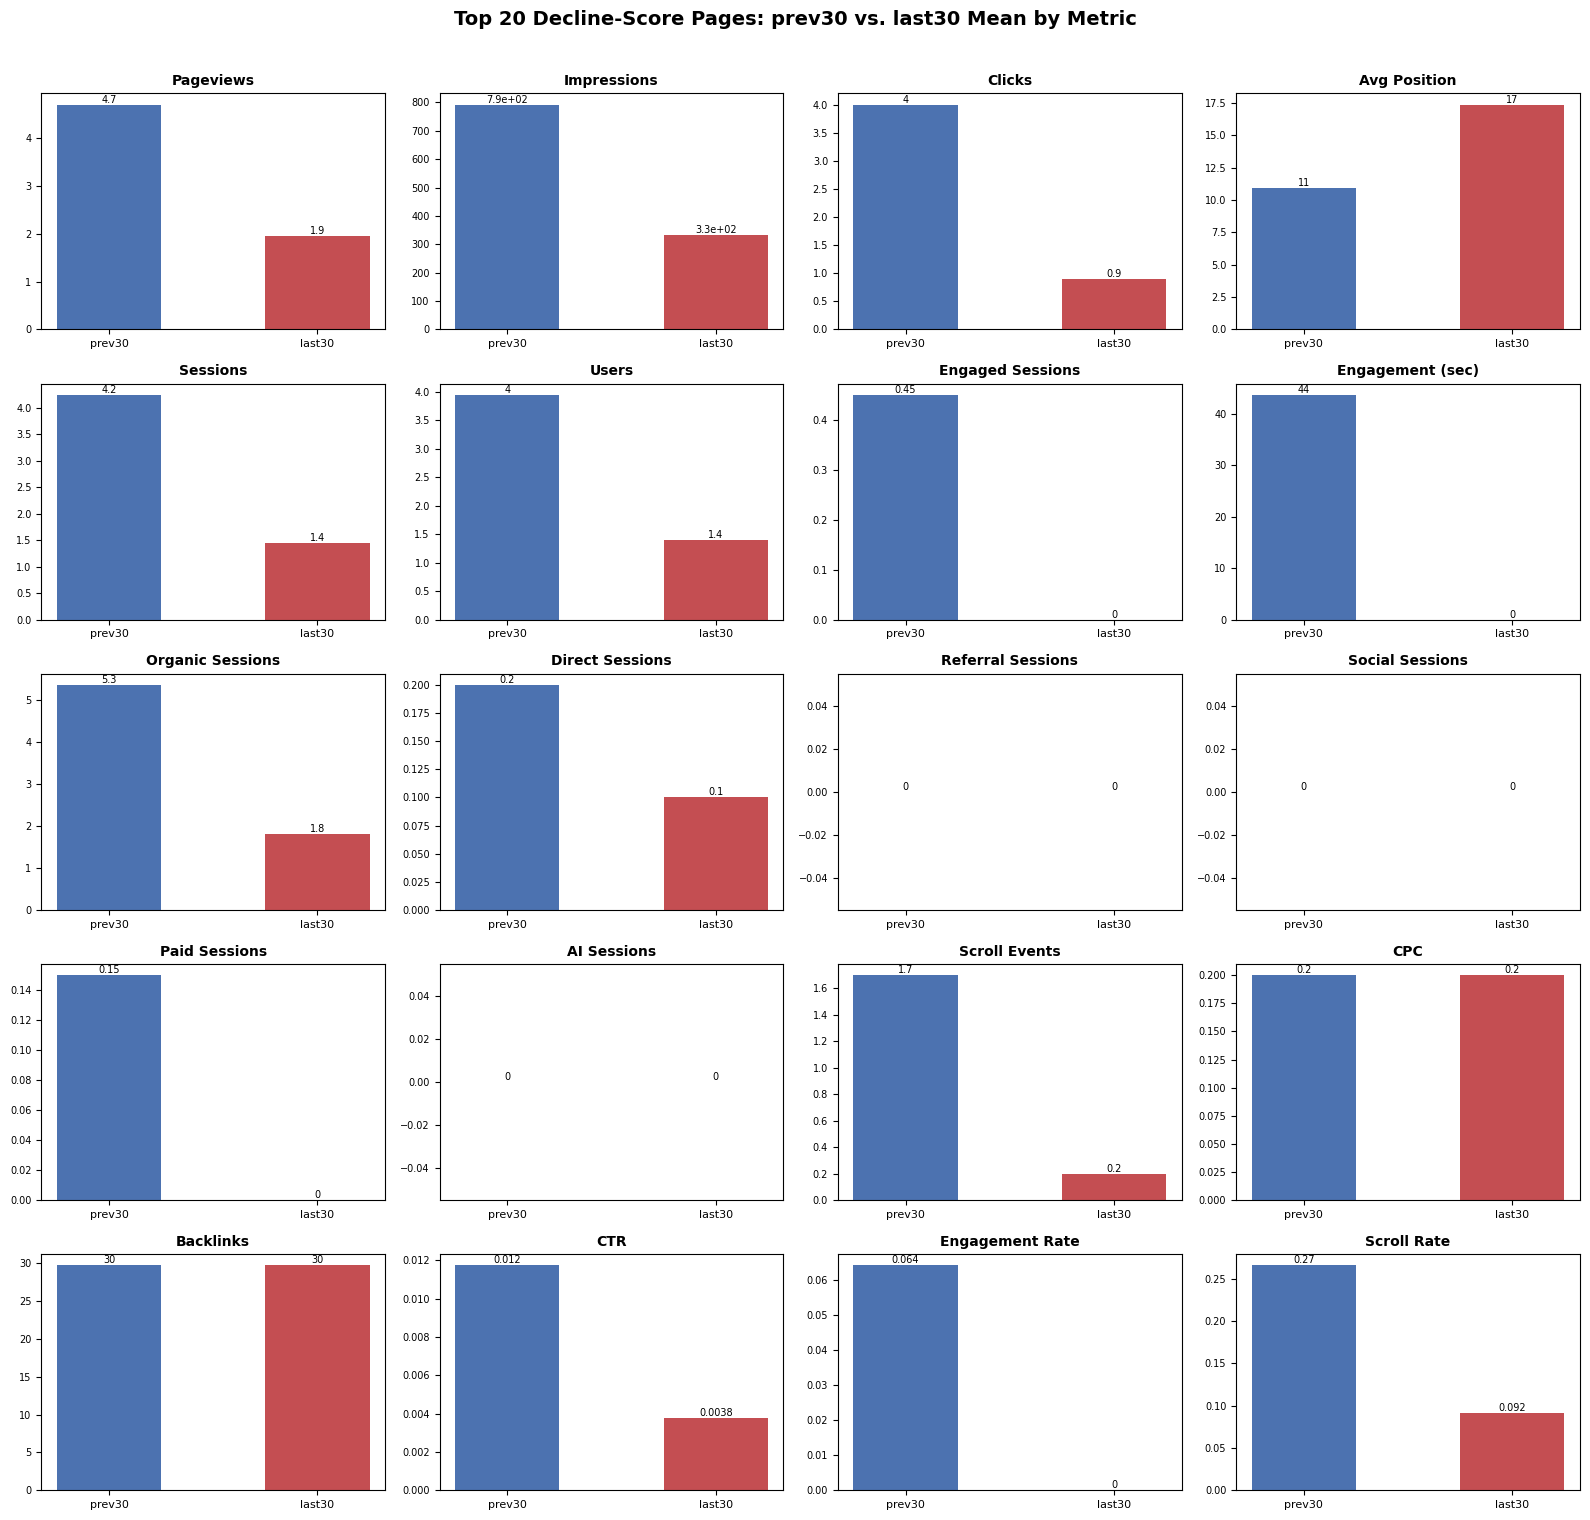

In [10]:
metric_pairs = [
    ('ga4_pageviews_prev30d', 'ga4_pageviews_last30d', 'Pageviews'),
    ('gsc_impressions_prev30d', 'gsc_impressions_last30d', 'Impressions'),
    ('gsc_clicks_prev30d', 'gsc_clicks_last30d', 'Clicks'),
    ('gsc_avg_position_prev30d', 'gsc_avg_position_last30d', 'Avg Position'),
    ('ga4_sessions_prev30d', 'ga4_sessions_last30d', 'Sessions'),
    ('ga4_users_prev30d', 'ga4_users_last30d', 'Users'),
    ("'ga4_engaged_session_prev30", "'ga4_engaged_session_last30", 'Engaged Sessions'),
    ('ga4_total_engagement_sec_prev30', 'ga4_total_engagement_sec_last30', 'Engagement (sec)'),
    ('sessions_organic_prev30', 'sessions_organic_last30', 'Organic Sessions'),
    ('sessions_direct_prev30', 'sessions_direct_last30', 'Direct Sessions'),
    ('sessions_referral_prev30', 'sessions_referral_last30', 'Referral Sessions'),
    ('sessions_social_prev30', 'sessions_social_last30', 'Social Sessions'),
    ('sessions_paid_prev30', 'sessions_paid_last30', 'Paid Sessions'),
    ('sessions_ai_prev30', 'sessions_ai_last30', 'AI Sessions'),
    ('scroll_events_prev30', 'scroll_events_last30', 'Scroll Events'),
    ('cpc_prev30', 'cpc_last30', 'CPC'),
    ('backlinks_prev30', 'backlinks_last30', 'Backlinks'),
    ('ctr_prev30', 'ctr_last30', 'CTR'),
    ('engagement_rate_prev30', 'engagement_rate_last30', 'Engagement Rate'),
    ('scroll_events_rate_prev30', 'scroll_events_rate_last30', 'Scroll Rate'),
]

n_metrics = len(metric_pairs)
n_cols = 4
n_rows = -(-n_metrics // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for i, (prev_col, last_col, label) in enumerate(metric_pairs):
    ax = axes[i]
    prev_mean = top_queue[prev_col].mean()
    last_mean = top_queue[last_col].mean()

    bars = ax.bar(['prev30', 'last30'], [prev_mean, last_mean],
                   color=['#4C72B0', '#C44E52'], width=0.5)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=7)

    for bar, val in zip(bars, [prev_mean, last_mean]):
        ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.2g}',
                ha='center', va='bottom', fontsize=7)

# hide unused subplots
for j in range(n_metrics, len(axes)):
    axes[j].axis('off')

fig.suptitle('Top 20 Decline-Score Pages: prev30 vs. last30 Mean by Metric', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('work/outputs/top20_prev_vs_last_grid.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Who uses and for what?**<br>
The people who uses SEO can use this as a decision-support to work on pages which needs a refresh instead of manually see and analyze pages.<br>
This proxy label is a prioritization signal, not an autonomous decision system. It ranks content by likelihood of decline based on decline_score, a proxy label built from 17 rule-based conditions (search visibility, CTR, engagement, traffic across channels, and others) comparing a prev30 to a last30 window. Its intended use is to help a human reviewer decide which pages to look at first, and not to trigger automatic content changes, and not to diagnose the specific cause of decline.<br>
**Limitations**<br>
1. These signals are measured from the difference in signals of 2 months, so it has limitation to very long duration content pages.
2. Model reliability varies sharply by class: <br>
    (precision)    (recall)  (f1-score)   (support)

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        17
           5       0.32      0.17      0.22       528
           6       0.40      0.53      0.46      2444
           7       0.43      0.54      0.48      4380
           8       0.39      0.39      0.39      4165
           9       0.41      0.44      0.43      4576
          10       0.46      0.44      0.45      7599
          11       0.50      0.58      0.54     11618
          12       0.52      0.50      0.51     13127
          13       0.55      0.54      0.55     14309
          14       0.55      0.55      0.55     15054
          15       0.67      0.63      0.65     23393
          16       0.71      0.80      0.75     30413
          17       0.87      0.58      0.70     14836

    (accuracy)                           0.60    146461 <br>
   (macro avg)       0.45  //    0.45 // 0.44 // 146461 <br>
(weighted avg)       0.61  //    0.60 // 0.60 // 146461 <br>

The classifier's macro F1 is [0.444-0.58, using RandomForest on 10 n_estimators], with strong performance at the extremes (class 16: F1 0.75; class 17: somehow similarly strong) and weak performance in the middle range (classes 8-13: F1 0.39-0.55). Classes with very few training examples (3, 4) are effectively unlearnable and should not be trusted at all.

**Plots**

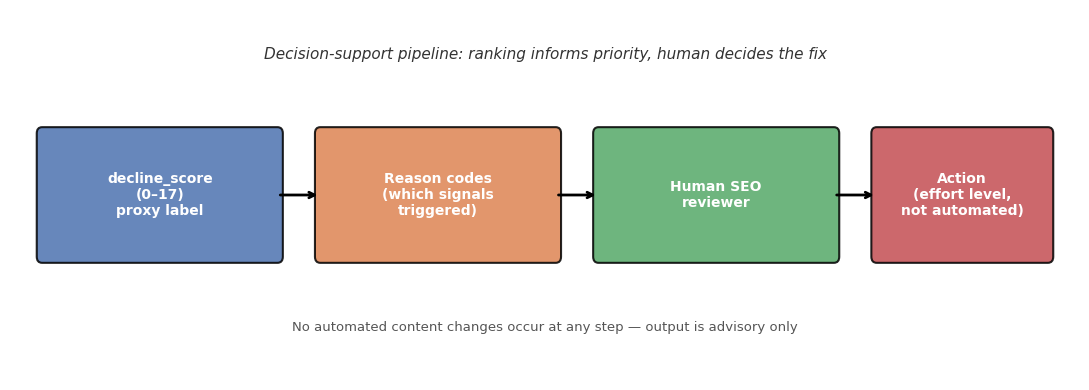

In [11]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

fig, ax = plt.subplots(figsize=(11, 4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 3)
ax.axis('off')

boxes = [
    (0.3, 1, 2.2, 1, '#4C72B0', "decline_score\n(0–17)\nproxy label"),
    (2.9, 1, 2.2, 1, '#DD8452', "Reason codes\n(which signals\ntriggered)"),
    (5.5, 1, 2.2, 1, '#55A868', "Human SEO\nreviewer"),
    (8.1, 1, 1.6, 1, '#C44E52', "Action\n(effort level,\nnot automated)"),
]

for x, y, w, h, color, label in boxes:
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05",
                          linewidth=1.5, edgecolor='black', facecolor=color, alpha=0.85)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center',
            fontsize=10, color='white', fontweight='bold')

arrow_positions = [(2.5, 1.5, 2.9, 1.5), (5.1, 1.5, 5.5, 1.5), (7.7, 1.5, 8.1, 1.5)]
for x1, y1, x2, y2 in arrow_positions:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', lw=2, color='black'))

ax.text(5, 2.6, 'Decision-support pipeline: ranking informs priority, human decides the fix',
        ha='center', fontsize=11, style='italic', color='#333333')
ax.text(5, 0.4, 'No automated content changes occur at any step — output is advisory only',
        ha='center', fontsize=9.5, color='#555555')

plt.tight_layout()
plt.savefig('work/outputs/decision_support_workflow.png', dpi=300, bbox_inches='tight')
plt.show()

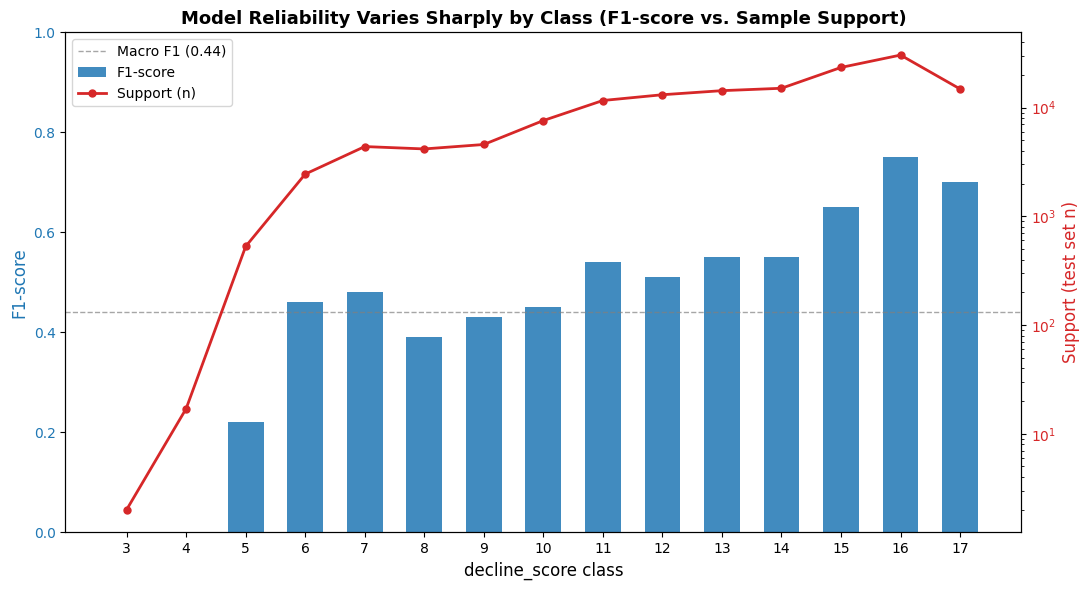

In [12]:
classes = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
f1_scores = [0.00, 0.00, 0.22, 0.46, 0.48, 0.39, 0.43, 0.45, 0.54, 0.51, 0.55, 0.55, 0.65, 0.75, 0.70]
support = [2, 17, 528, 2444, 4380, 4165, 4576, 7599, 11618, 13127, 14309, 15054, 23393, 30413, 14836]

fig, ax1 = plt.subplots(figsize=(11, 6))
ax1.bar(classes, f1_scores, color='#1f77b4', alpha=0.85, width=0.6, label='F1-score')
ax1.set_xlabel('decline_score class', fontsize=12)
ax1.set_ylabel('F1-score', color='#1f77b4', fontsize=12)
ax1.set_ylim(0, 1.0)
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_xticks(classes)
ax1.axhline(0.44, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Macro F1 (0.44)')

ax2 = ax1.twinx()
ax2.plot(classes, support, color='#d62728', marker='o', linewidth=2, markersize=5, label='Support (n)')
ax2.set_ylabel('Support (test set n)', color='#d62728', fontsize=12)
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor='#d62728')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.title('Model Reliability Varies Sharply by Class (F1-score vs. Sample Support)', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('work/outputs/f1_by_class_support.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**What person must check?**<br>
The person must check the decline_score, the higher it is, the greater the urgency to deal with that page. Beyond the score, the reviewer must look into what problem the page is actually facing and decide the fix themselves; the model does not diagnose this. Scores for classes 3–4 (almost no training data) or in the 8–13 range (weakest reliability) should be treated with added skepticism before acting
**What should never be automated?**<br>
Automatically triggering a refresh or deciding the specific type of problem is never something the model does — that judgment stays with the person

**Plots**

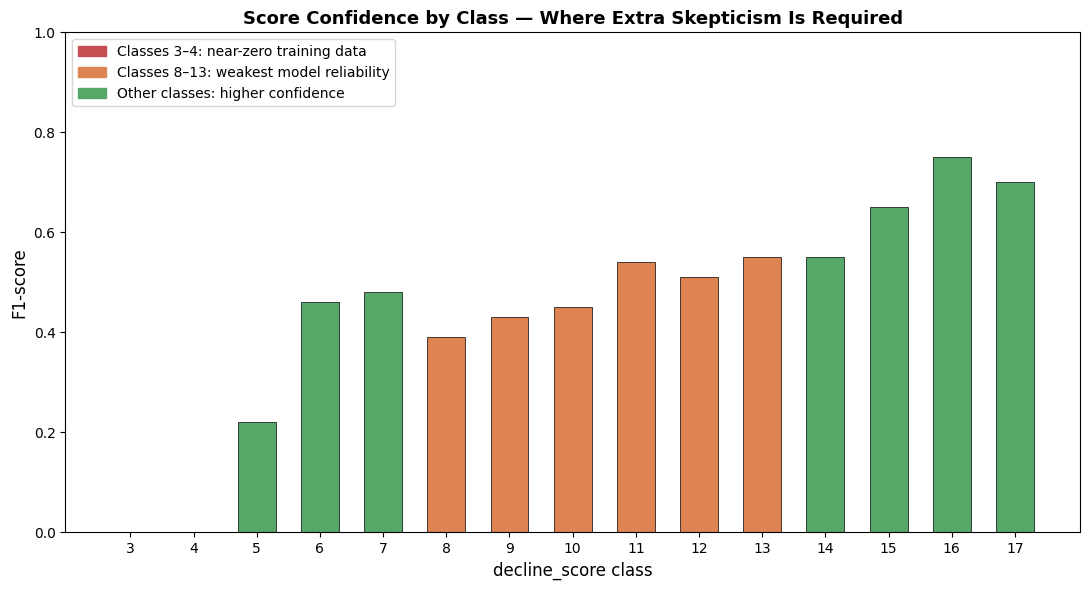

In [13]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# --- Figure 1: Confidence tiers by class — for "What person must check?" ---

classes = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
f1_scores = [0.00, 0.00, 0.22, 0.46, 0.48, 0.39, 0.43, 0.45, 0.54, 0.51, 0.55, 0.55, 0.65, 0.75, 0.70]

confidence_tier = []
colors = []
for c, f1 in zip(classes, f1_scores):
    if c in [3, 4]:
        confidence_tier.append('Near-zero data')
        colors.append('#C44E52')
    elif 8 <= c <= 13:
        confidence_tier.append('Weakest reliability')
        colors.append('#DD8452')
    else:
        confidence_tier.append('Higher confidence')
        colors.append('#55A868')

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(classes, f1_scores, color=colors, width=0.6, edgecolor='black', linewidth=0.5)

ax.set_xlabel('decline_score class', fontsize=12)
ax.set_ylabel('F1-score', fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_xticks(classes)
ax.set_title('Score Confidence by Class — Where Extra Skepticism Is Required', fontsize=13, fontweight='bold')

legend_elements = [
    plt.Rectangle((0,0),1,1, color='#C44E52', label='Classes 3–4: near-zero training data'),
    plt.Rectangle((0,0),1,1, color='#DD8452', label='Classes 8–13: weakest model reliability'),
    plt.Rectangle((0,0),1,1, color='#55A868', label='Other classes: higher confidence'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('work/outputs/confidence_tiers_by_class.png', dpi=300, bbox_inches='tight')
plt.show()

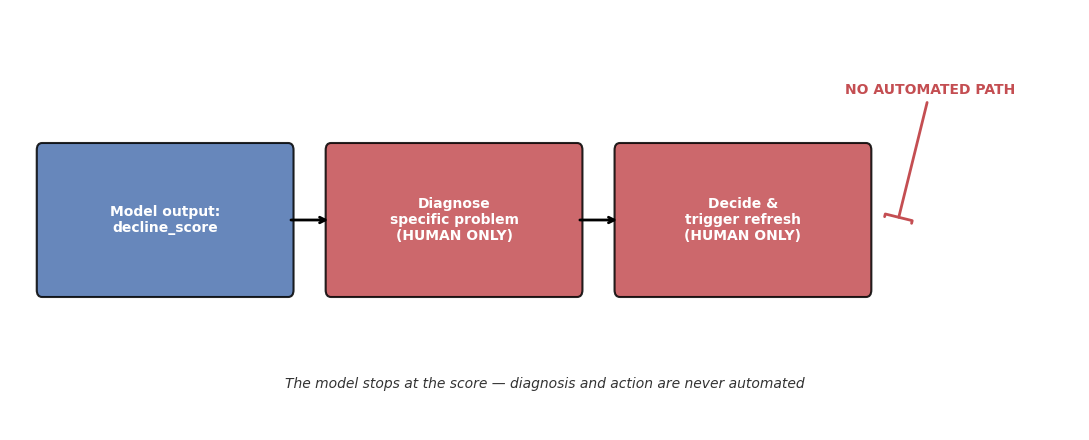

In [14]:
# --- Figure 2: Human-only steps — for "What should never be automated?" ---

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 3)
ax.axis('off')

steps = [
    (0.3, 1, 2.3, 1, '#4C72B0', "Model output:\ndecline_score"),
    (3.0, 1, 2.3, 1, '#C44E52', "Diagnose\nspecific problem\n(HUMAN ONLY)"),
    (5.7, 1, 2.3, 1, '#C44E52', "Decide &\ntrigger refresh\n(HUMAN ONLY)"),
]

for x, y, w, h, color, label in steps:
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05",
                          linewidth=1.5, edgecolor='black', facecolor=color, alpha=0.85)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center',
            fontsize=10, color='white', fontweight='bold')

ax.annotate('', xy=(3.0, 1.5), xytext=(2.6, 1.5),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))
ax.annotate('', xy=(5.7, 1.5), xytext=(5.3, 1.5),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))

ax.annotate('NO AUTOMATED PATH', xy=(8.3, 1.5), xytext=(8.6, 2.4),
            fontsize=10, color='#C44E52', fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='-[', lw=2, color='#C44E52'))

ax.text(5, 0.3, 'The model stops at the score — diagnosis and action are never automated',
        ha='center', fontsize=10, style='italic', color='#333333')

plt.tight_layout()
plt.savefig('work/outputs/never_automated_steps.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**The recommendations go stale when:**<br>
(1) more than 30 days pass without regenerating the queue, since the underlying window shifts; <br>(2) a known external event (algorithm update, seasonality) could invalidate the baseline assumptions; <br>(3) human reviewers begin reporting a rising false-positive rate on top-ranked pages. <br>
Only (1) can be measured directly from existing data today; (2) and (3) require monitoring processes (a control-page baseline check, a reviewer feedback log) that don't yet exist and would need to be set up going forward.

**Plots**

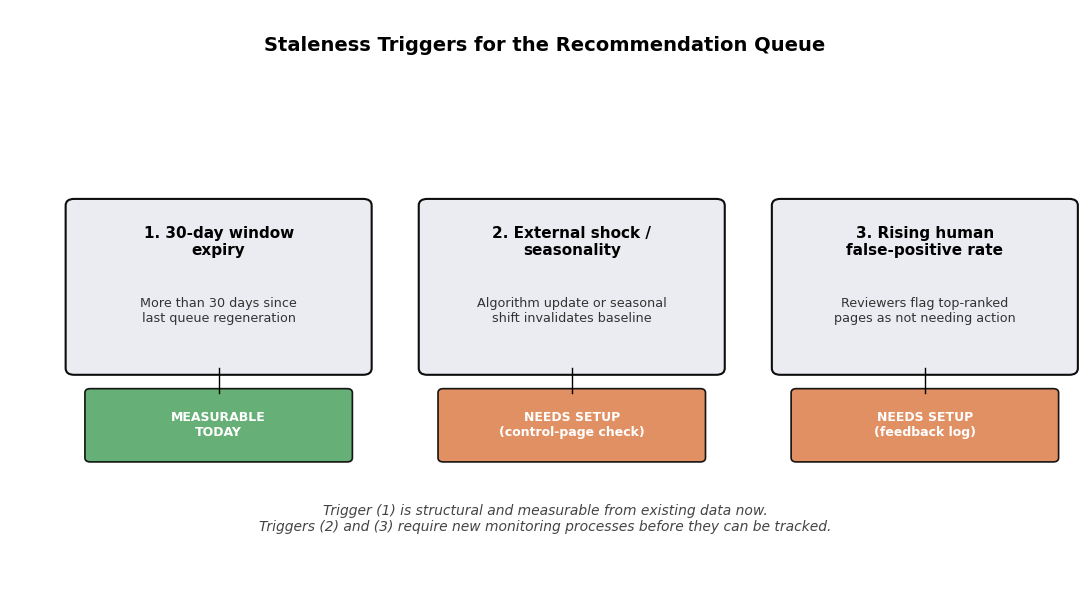

In [15]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

fig, ax = plt.subplots(figsize=(11, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.axis('off')

ax.text(5, 6.5, 'Staleness Triggers for the Recommendation Queue',
        ha='center', fontsize=14, fontweight='bold')

triggers = [
    (1, '30-day window\nexpiry',
     'More than 30 days since\nlast queue regeneration',
     'MEASURABLE\nTODAY', '#55A868'),
    (2, 'External shock /\nseasonality',
     'Algorithm update or seasonal\nshift invalidates baseline',
     'NEEDS SETUP\n(control-page check)', '#DD8452'),
    (3, 'Rising human\nfalse-positive rate',
     'Reviewers flag top-ranked\npages as not needing action',
     'NEEDS SETUP\n(feedback log)', '#DD8452'),
]

x_positions = [0.6, 3.9, 7.2]
width = 2.7

for (num, title, desc, status, color), x in zip(triggers, x_positions):
    # main box
    box = FancyBboxPatch((x, 2.6), width, 2.0, boxstyle="round,pad=0.08",
                          linewidth=1.5, edgecolor='black', facecolor='#EAEAF2', alpha=0.95)
    ax.add_patch(box)
    ax.text(x + width/2, 4.15, f'{num}. {title}', ha='center', va='center',
            fontsize=11, fontweight='bold')
    ax.text(x + width/2, 3.3, desc, ha='center', va='center', fontsize=9.2, color='#333333')

    # status badge
    badge = FancyBboxPatch((x + 0.15, 1.5), width - 0.3, 0.8, boxstyle="round,pad=0.05",
                            linewidth=1.2, edgecolor='black', facecolor=color, alpha=0.9)
    ax.add_patch(badge)
    ax.text(x + width/2, 1.9, status, ha='center', va='center',
            fontsize=9, fontweight='bold', color='white')

    # connector line
    ax.plot([x + width/2, x + width/2], [2.6, 2.3], color='black', linewidth=1)

ax.text(5, 0.6, 'Trigger (1) is structural and measurable from existing data now.\n'
                'Triggers (2) and (3) require new monitoring processes before they can be tracked.',
        ha='center', fontsize=10, style='italic', color='#444444')

plt.tight_layout()
plt.savefig('work/outputs/staleness_triggers.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [16]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
ranked_queue[:20].to_csv('work/outputs/ranked_queue.csv', index=False)
""" Note: the figures are all saved in work/outputs when plots were made in each of their respective cells"""

' Note: the figures are all saved in work/outputs when plots were made in each of their respective cells'

## Self-check

Before you submit, confirm each line honestly:

- [✓] Every section above is filled — markdown thinking AND the code that backs it
- [✓] The notebook runs top to bottom with no errors (Runtime → Run all)
- [✓] No client names, URLs, or private queries anywhere
- [✓] My claims use careful words: observed, measured, directional, decision-support
- [✓] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.